# Statystyka moja pasja (raport o fetcherze)

## Przegląd rozwiazań

Okazuje się, że wydajna implementacja komunikacji protokołem HTTP jest trudna. Wiele klientów oferuje rozwiązania, które są (stabilnie) kilkukrotnie wolniejsze od opymalnego, dodatkowo implementacja HTTP/3 również wydaje się sprawiać problemy. Wyniki testowanych rozwiązań:

| tech            | http/2                       | http/3               | komentarz                                                                           |
|-----------------|------------------------------|----------------------|-------------------------------------------------------------------------------------|
| python pycurl   | ok                           | ok                   | wsparcie http/3 tylko przy kompilacji ze źródeł                                     |
| python aiohttp  | brak                         | brak                 | z testów (dla `pycurla`) wynika, że asyncio request http/1.1 nie są aż takie wolne  |
| python requests | brak                         | brak                 |                                                                                     |
| python niquests | zepsute (8x wolniej)         | zepsute (3x wolniej) | fork `requests` ze wsparciem (mało wydajnym) http/2, http/3                         |
| python httpx    | zepsute (brak multiplexingu) | brak                 | fork `hyper`                                                                        |
| c++ cpr         | zepsute                      | brak                 | na ~10 uruchomień sukcesem kończy się jedno, dodatkowo trzeba walczyć z segfaultami |
| rust reqwest    | ok                           | brak                 |                                                                                     |
| rust quinn      | brak                         | ok                   |                                                                                     |

Gdzie wpis `ok` oznacza (stabline) osiąganie wyników, które będą zaprezentowane w dalszej części raportu i wierzymy, że są one blisko optymalnych.

Problemy występują także z serwerami:

| tech             | http/2             | http/3               | komentarz                                                                   |
|------------------|--------------------|----------------------|-----------------------------------------------------------------------------|
| python uvicorn   | ok (1.25x wolniej) | brak                 | standard fastapi                                                            |
| python hypercorn | ok (1.25x wolniej) | zepsute (3x wolniej) | fork uvicorna ze wsparciem http/3, niestety mało wydajnym                   |
| nginx            | ok                 | ok                   | na debianie / ubuntu wsparcie http/3 tylko przy kompilacji ze źródeł        |

Wszystkie poniże testy zostały przeprowadzone z użyciem serwera `nginx` kompilowanego ze wsparciem dla HTTP/3. Był on uruchomiony na serwerze wirtualnym w Niemczech.


Przebieg testów:
1. niquests + reqwest + quinn @ hypercorn (wniosek: zblefione HTTP/2)
2. ... + cpr (wniosek: zblefiona implementacja)
3. ... + httpx (wniosek: brak implementacji pipeline'ingu HTTP/2)
4. pycurl + reqwest + quinn (wniosek: HTTP/3 jest podejrzanie wolne)
5. pycurl + reqwest + quinn @ nginx (działa!)

### Benchmarki (tylko dla workerów)

Uwaga: poniższe wyniki raczej nie powinny służyć do porównywania technologii (rust / python) między sobą, bo każdy test trwa kilkadziesiąt minut, a warunki sieciowe na WANie się zmieniają.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("./data_workers.csv.gz")
df

,tech,proto,workers,test,lan_conn,wan_conn,meta_time,blob_time
0,rust reqwest,http11,10,wan,wired,fo @ 300mbps,2826,7112
1,rust reqwest,http11,10,wan,wired,fo @ 300mbps,2813,6565
2,rust reqwest,http11,10,wan,wired,fo @ 300mbps,2842,6753
3,rust reqwest,http11,10,wan,wired,fo @ 300mbps,2861,6561
4,rust reqwest,http11,10,wan,wired,fo @ 300mbps,2842,6967
...,...,...,...,...,...,...,...,...
1075,python pycurl (uvloop),http3,250,wan,wireless 2.4ghz,fo @ 300mbps,838,26287
1076,python pycurl (uvloop),http3,250,wan,wireless 2.4ghz,fo @ 300mbps,832,27933
1077,python pycurl (uvloop),http3,250,wan,wireless 2.4ghz,fo @ 300mbps,867,30521
1078,python pycurl (uvloop),http3,250,wan,wireless 2.4ghz,fo @ 300mbps,835,28158


### Wired

In [3]:
grouped_wired = df.loc[df["lan_conn"] == "wired"].groupby(["proto", "tech"])

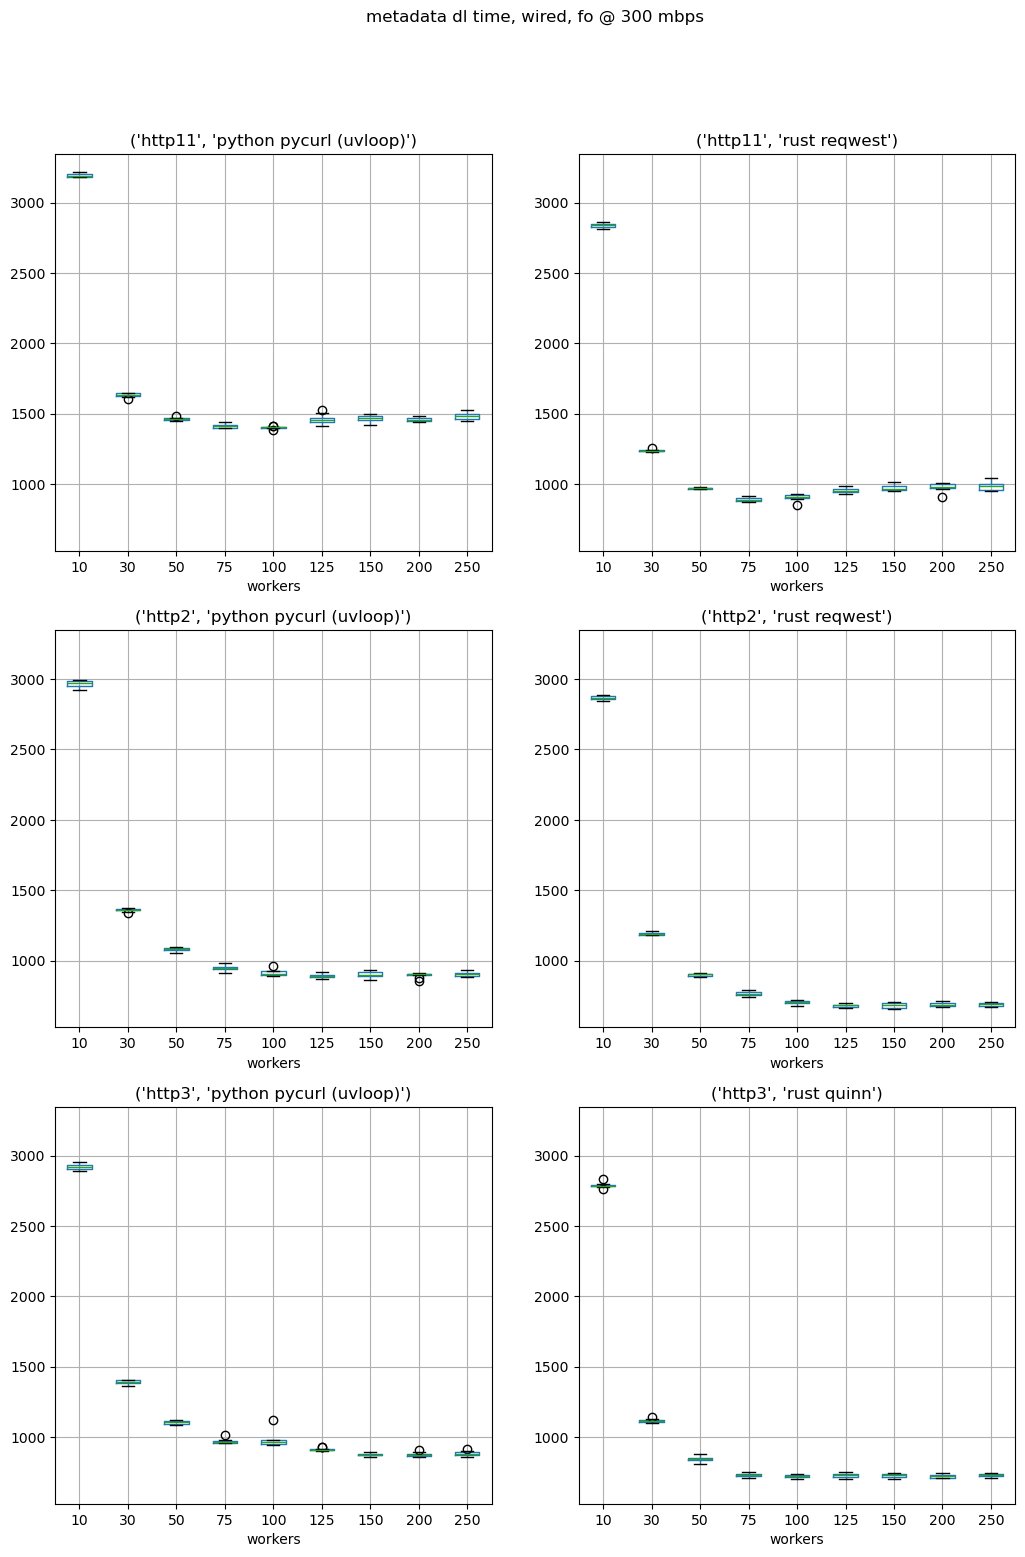

In [4]:
fig, axes = plt.subplots(len(grouped_wired)//2, 2, figsize=(12,18))
axes = axes.flatten()

for ax, (label, plot_data) in zip(axes, grouped_wired):
    plot_data.boxplot(column=["meta_time"], by="workers", ax=ax)
    ax.set_title(label)
    ax.sharey(axes[0])
    
plt.suptitle("metadata dl time, wired, fo @ 300 mbps")
plt.show()

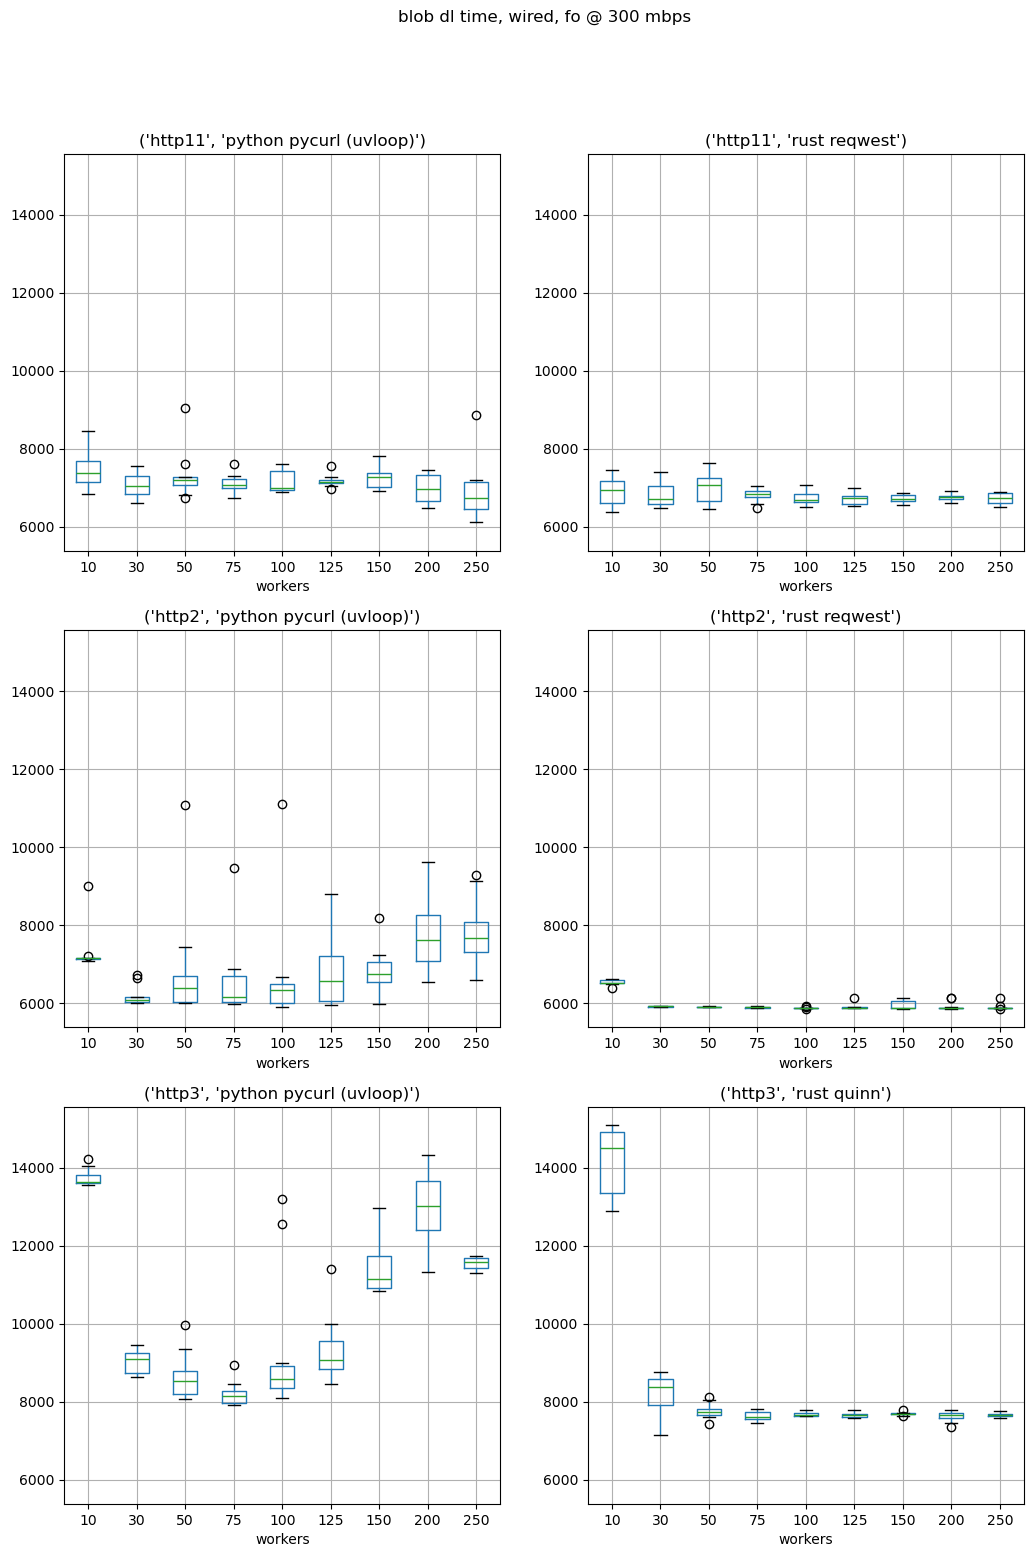

In [5]:
fig, axes = plt.subplots(len(grouped_wired)//2, 2, figsize=(12,18))
axes = axes.flatten()

for ax, (label, plot_data) in zip(axes, grouped_wired):
    plot_data.boxplot(column=["blob_time"], by="workers", ax=ax)
    ax.set_title(label)
    ax.sharey(axes[0])


plt.suptitle("blob dl time, wired, fo @ 300 mbps")
plt.show()

### Wireless

In [6]:
grouped_wireless = df.loc[df["lan_conn"] == "wireless 2.4ghz"].groupby(["proto", "tech"])

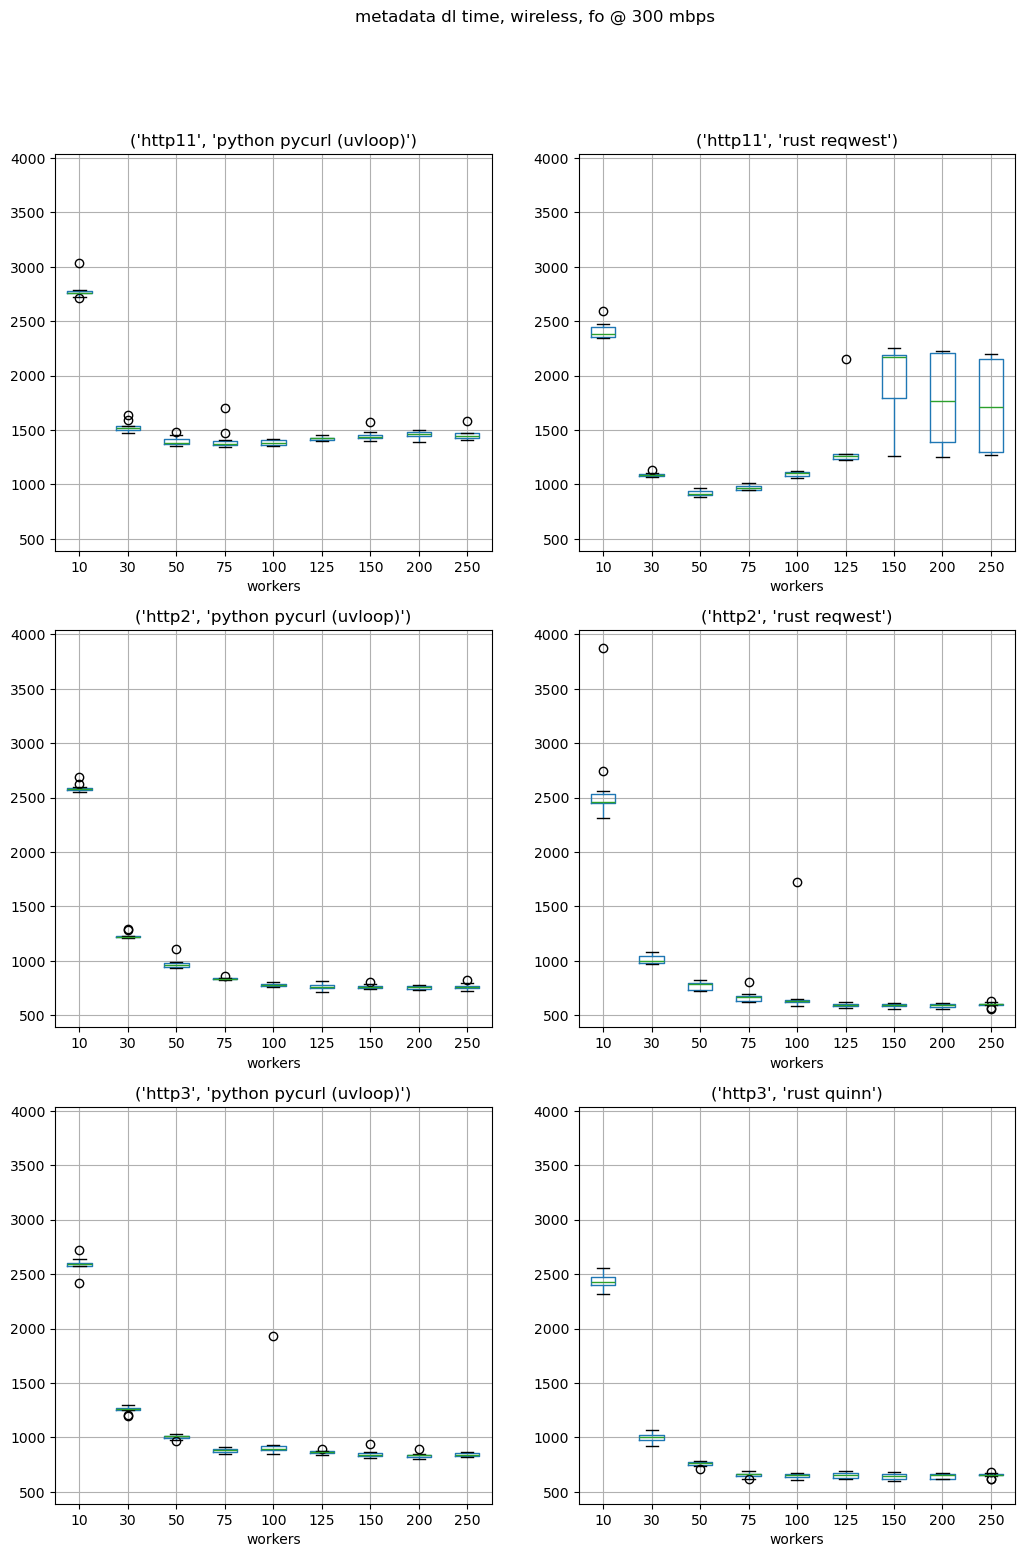

In [7]:
fig, axes = plt.subplots(len(grouped_wireless)//2, 2, figsize=(12,18))
axes = axes.flatten()

for ax, (label, plot_data) in zip(axes, grouped_wireless):
    plot_data.boxplot(column=["meta_time"], by="workers", ax=ax)
    ax.set_title(label)
    ax.sharey(axes[0])
    
plt.suptitle("metadata dl time, wireless, fo @ 300 mbps")
plt.show()

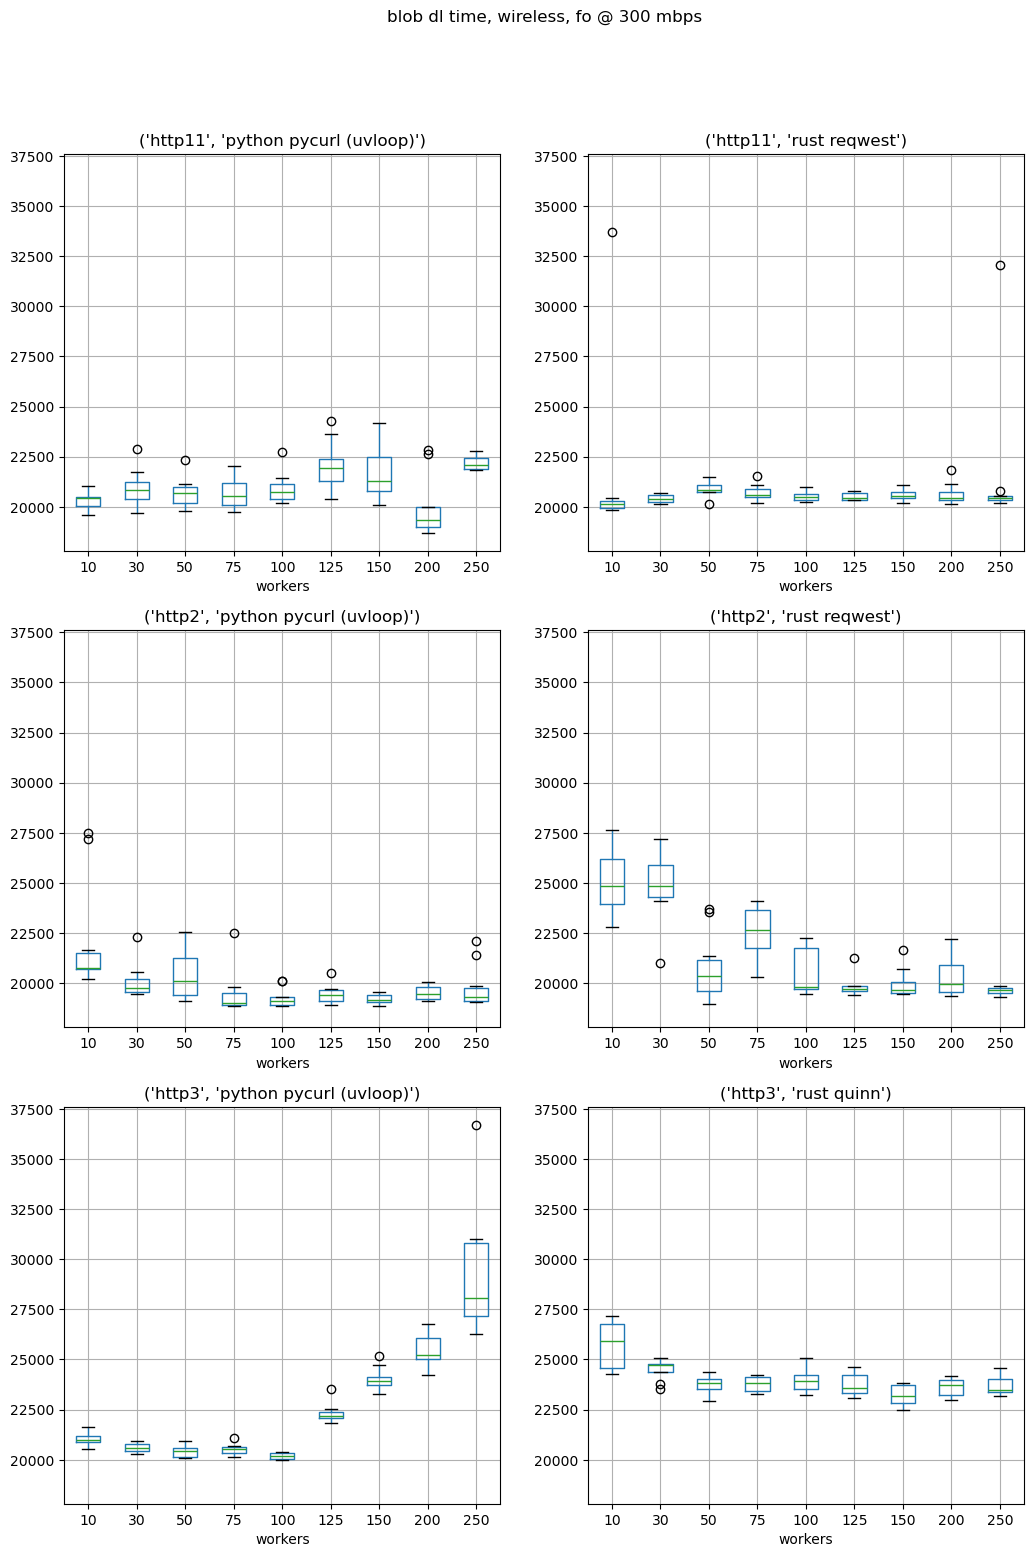

In [8]:
fig, axes = plt.subplots(len(grouped_wireless)//2, 2, figsize=(12,18))
axes = axes.flatten()

for ax, (label, plot_data) in zip(axes, grouped_wireless):
    plot_data.boxplot(column=["blob_time"], by="workers", ax=ax)
    ax.set_title(label)
    ax.sharey(axes[0])
    
plt.suptitle("blob dl time, wireless, fo @ 300 mbps")
plt.show()

## Benchmarki

In [9]:
df = pd.read_csv("./data.csv.gz")
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df

,tech,proto,workers,test,lan_conn,wan_conn,meta_time,blob_time,timestamp
0,python pycurl (uvloop),http11,50,wan,wired,fo @ 300mbps,1446,7081,2025-02-26 22:01:51
1,python pycurl (uvloop),http11,80,wan,wired,fo @ 300mbps,1413,7024,2025-02-26 22:02:03
2,python pycurl (uvloop),http11,100,wan,wired,fo @ 300mbps,1399,7011,2025-02-26 22:02:14
3,python pycurl (uvloop),http11,200,wan,wired,fo @ 300mbps,1459,6768,2025-02-26 22:02:25
4,rust reqwest,http2,50,wan,wired,fo @ 300mbps,885,5939,2025-02-26 22:02:37
...,...,...,...,...,...,...,...,...,...
1195,python pycurl (uvloop),http3,200,wan,wired,fo @ 300mbps,860,11025,2025-02-27 05:22:25
1196,rust quinn,http3,50,wan,wired,fo @ 300mbps,835,7592,2025-02-27 05:22:40
1197,rust quinn,http3,80,wan,wired,fo @ 300mbps,730,7683,2025-02-27 05:22:52
1198,rust quinn,http3,100,wan,wired,fo @ 300mbps,703,7617,2025-02-27 05:23:04


In [10]:
grouped_wired = df.loc[df["lan_conn"] == "wired"].groupby(["proto", "tech"])

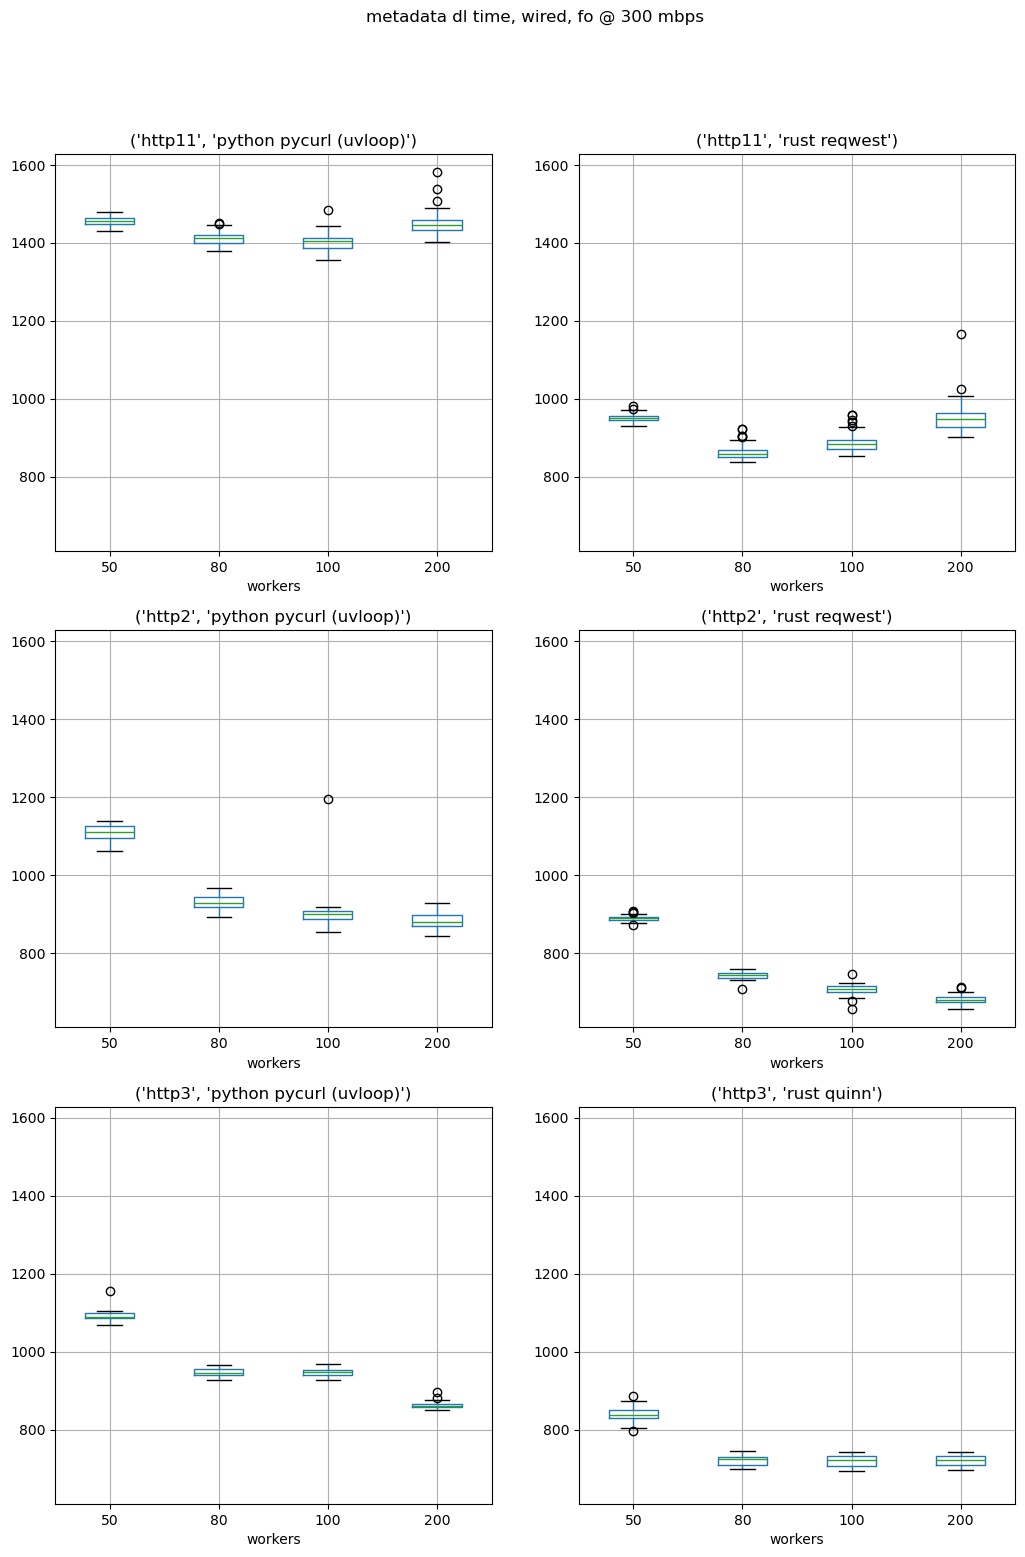

In [11]:
fig, axes = plt.subplots(len(grouped_wired)//2, 2, figsize=(12,18))
axes = axes.flatten()

for ax, (label, plot_data) in zip(axes, grouped_wired):
    plot_data.boxplot(column=["meta_time"], by="workers", ax=ax)
    ax.set_title(label)
    ax.sharey(axes[0])
    
plt.suptitle("metadata dl time, wired, fo @ 300 mbps")
plt.show()

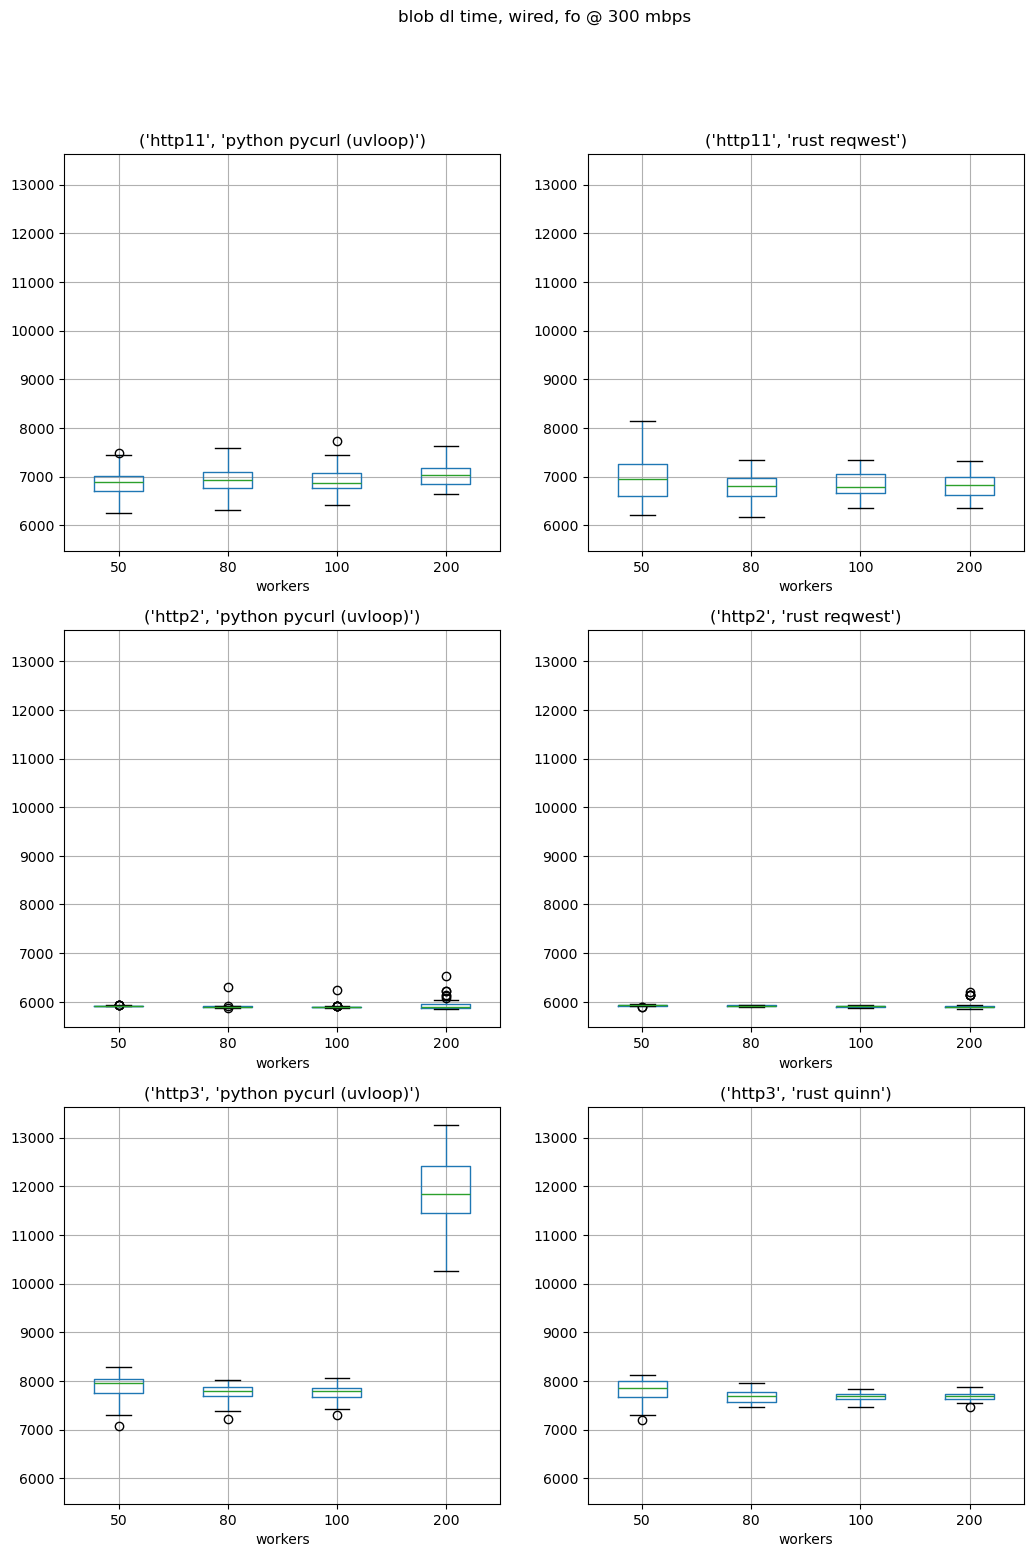

In [12]:
fig, axes = plt.subplots(len(grouped_wired)//2, 2, figsize=(12,18))
axes = axes.flatten()

for ax, (label, plot_data) in zip(axes, grouped_wired):
    plot_data.boxplot(column=["blob_time"], by="workers", ax=ax)
    ax.set_title(label)
    ax.sharey(axes[0])


plt.suptitle("blob dl time, wired, fo @ 300 mbps")
plt.show()